# Orlanski Scheme Error Diagnostics

Diagnostic notebook for the errors of the **2D Orlanski radiation scheme** at the eastern open boundary
(module: `../OSSWEM_helpers/Remove_periodicity_2D_NS_orlanski.py`, driver `run_obc`).

**Setup** (configuration unchanged from the parent OBC notebooks): barotropically unstable channel jet;
western sponge (300 km) + N/S near-wall sponges restoring toward the balanced jet; control (truth) run records
the west-band columns and a probe at columns `[b_obc-2, b_obc-1, b_obc]` **every step**; the OBC run prescribes the
west band from the control, applies the 2D Orlanski scheme at the east column `b_obc` (inflow rows nudged toward
the recorded external col-`b` data with coefficient `ALPHA_IN`), and stores its own per-step probe at `b_obc-1`
(`rx_2d['probe']`, module hook `[OBC - 2D - Probe]`).

**Hypotheses under test**
1. **Spurious inflow (Diagnostic 1)** — the scheme's estimated normal phase speed is frequently *negative*
   ($r_x<0$ → row treated as inflow and prescribed/nudged) even though boundary features are advected by the
   (mostly eastward) flow: the theory reference $c_{th} = u$ at `b_obc-1` is predominantly positive, and the fast
   characteristic $u + \sqrt{gh}$ is *always* positive here.
2. **Non-physical magnitude (Diagnostic 2)** — even on outflow rows, $c_x = r_x\,dx/dt$ is set by grid-scale
   noise, the `eps_denom` floor, and the $r_x \le 3$ clamp rather than by a physical propagation speed.

Reference numbers for this configuration: jet peak $= 1$ m/s (the advective $c_{th}$ scale),
$\sqrt{g H_o} = \sqrt{0.08 \cdot 800} = 8$ m/s (gravity-wave bound), $dx/dt = 10\,\mathrm{km}/200\,\mathrm{s} = 50$ m/s
(so $r_x = 1 \leftrightarrow 50$ m/s; advective $r_x \approx 0.02$; the outflow clamp $r_x = 3 \leftrightarrow 150$ m/s).

*Removed relative to the parent notebook: the 1D-Orlanski run and everything depending on it, all animations
(h/u/PV panel movies, column-profile movies), the center-line Hovmöller (1D-module-only feature), and scratch cells.
A byte-identical backup of the previous version is kept as `Orlanski_Scheme_Diagnostic.ipynb.bak`.*


In [1]:
import sys
sys.path.insert(0, '../OSSWEM_helpers')

import matplotlib.pyplot as plt
import numpy as np

from Remove_periodicity_2D_NS_orlanski import SSWEM as SSWEM_2D   #   the 2D-scheme module is the only module used now
SSWEM = SSWEM_2D   #   control run reuses the same class (1D-module import dropped; interior physics is identical, diff-checked)


## Configuration: channel jet, sponges, balanced initial state

Kept as-is from the parent notebook (grid, jet profile options, sponge-layer setup, balanced thickness, seed
perturbation, and the Rayleigh–Kuo / Charney–Stern instability check of the jet).


mesh: ni = 250  nj = 180
Grid: dx = 10000.0 [m]  dy = 10000.0 [m]
cg = 8.0 [m s-1]
Ld = 80000.0 [m]
Scales: Ls=epsilon/D/beta = None [m]
Scales: Lx/Ld = 31.25
Res: Ld/dx = 8.0


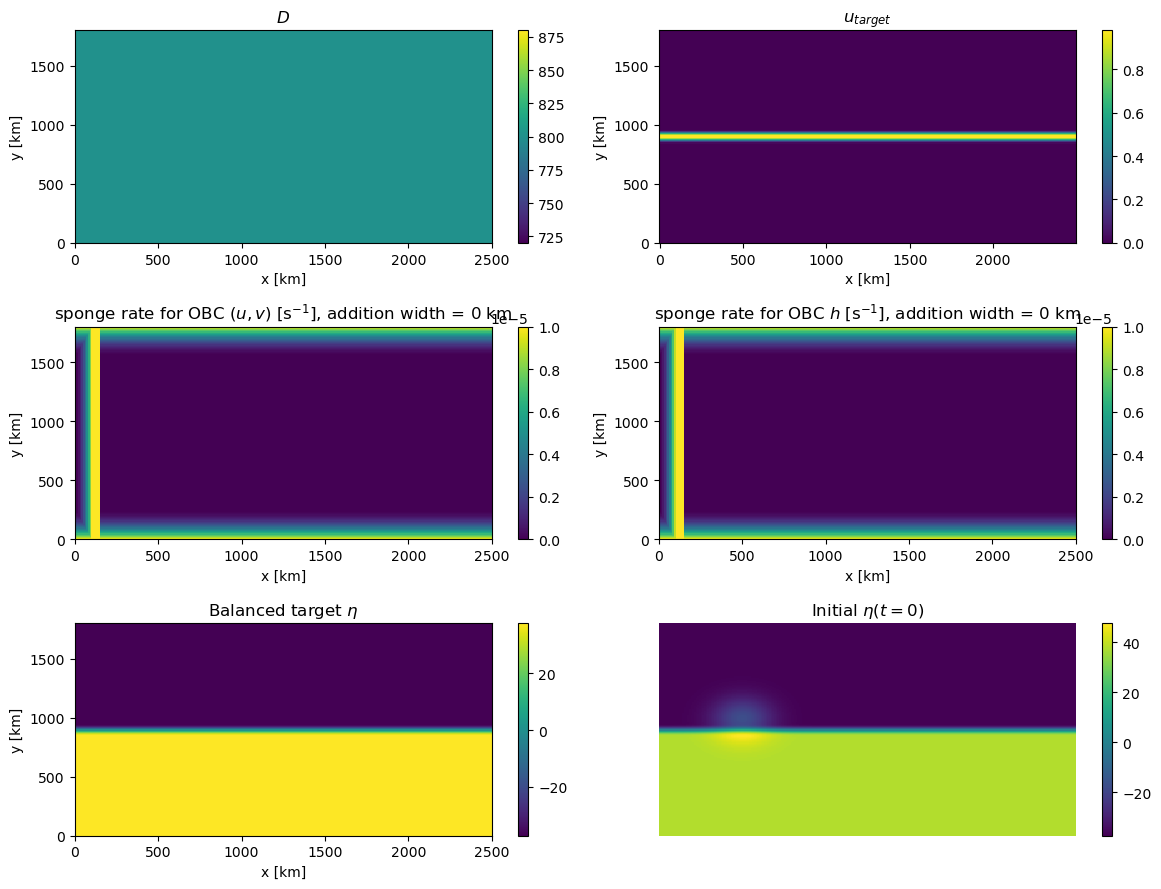

In [2]:
# Barotropic instability in a channel: a balanced zonal jet maintained by a
# localized western sponge (beta-plane).

# nj, ru_params = [dt, steps/segment, segments]
# nj, run_params = 40, [200., 500, 25]  # Barely permitted eddies
nj, run_params = 180, [200., 500, 100]  # Coarsest resolution with good instabilities
# nj, run_params = 120, [50., 2000, 100]  # Finer resolution
# nj, run_params = 180, [5., 5000, 100]  # Finer resolution is very unstable

# Resolution and Length Setting
dx = 10.e3
Lx = 2500.e3

M = SSWEM(int(Lx / dx),
          0.08,    # Gravity [m s-2]
          800.,    # Nominal layer thickness [m]
          Lx,  # Domain width [m]  (50% longer in x than y)
          1e-4,   # Coriolis [s-1]
          0, # df/dy [m-1 s-1]  (beta-plane arrests the large-scale meridional mode) used to be 3.0e-11
          2.5e-5,  # Bottom drag rate [m s-1]
          2e2,     # Lateral viscosity [m2 s-1]
          nj=nj,    # Rectangular channel
          )
# M.D[0,:] = 0       # dry rows N/S -> zonal channel walls
# M.D[-1,:] = 0

# Single jet
M.set_u_target_jet(1.0) 
# yc   = M.yu / M.Ly                                 
# hw   = 180e3 / M.Ly                               
# bump = lambda c: SSWEM._cubint(yc, c-hw, c) - SSWEM._cubint(yc, c, c+hw)
# profile = bump(1/2)                               
# M.u_target = np.empty_like(M.u)                    
# for k in range(M.nk):                            
#     M.u_target[k, :] = 2.5 * profile       
# yc   = M.yu / M.Ly                                 
# hw   = 100e3 / M.Ly                               
# bump = lambda c: SSWEM._cubint(yc, c-hw, c) - SSWEM._cubint(yc, c, c+hw)
# profile = bump(1/2)                               
# M.u_target = np.empty_like(M.u)                    
# for k in range(M.nk):                            
#     M.u_target[k, :] = 2.5 * profile         

# Double jet
# yc = M.yu / M.Ly                                   # non-dim y at u-points
# hw = 60e3 / M.Ly                                   # half-width of each jet (< Ly/6 so they don't overlap)
# bump = lambda c: SSWEM._cubint(yc, c-hw, c) - SSWEM._cubint(yc, c, c+hw)
# profile = 1.8 * (bump(2/5) + bump(3/5))                   # two eastward jets at y = 2Ly/5, 3Ly/5
# M.u_target = np.empty_like(M.u)
# for k in range(M.nk):
#     M.u_target[k, :] = 1.0 * profile               # 1.0 = peak speed [m/s]


uy  = M.u_target[0].mean(axis=1)                   # u(y)
f_h = M.fo + M.beta * M.yh1                        # f(y) at row centres
eta = -(1.0/M.g[0]) * np.cumsum(f_h * uy) * M.dy
eta -= eta.mean() # Why remove mean? 
hbal = np.maximum(M.D + eta[:, None], 0.0)         # balanced thickness
hbal[0, :] = hbal[1, 1]
hbal[-1, :] = hbal[-2, 1]

# ============================= Sponge Layer Setup ==============================================

# Sponges restoring u->jet, v->0, h->balanced: a western sponge over the westernmost
# 150 km, plus N/S near-wall sponges over the outer 100 km.
# Local forcing only; the rest of the domain is free to evolve.
factor = 1.5
def ramp(x, x0, Lx, p=2): return np.clip((x - x0)/(Lx - x0), 0, 1)**p
def ramp2(x, x0, Lx, factor=1.5): return np.clip(factor*(x - x0)/(Lx - x0), 0, 1)**2
# rate, Lw, yb = 1.0e-5, 150.e3, 100e3               # western sponge width Lw; near-wall band yb
rate_h, rate_uv, Lw_uv, Lw_h, yb = 1.e-5, 1.e-5, 150.e3, 150.e3, 250e3

rate_h_ns = rate_h
rate_uv_ns = rate_uv

ratio_temp = 0
width = ratio_temp * Lw_uv
# width = 0.e3
# width = 50.e3 # The additional width of the sponge layer

# Western sponge: the eastern ramp shifted to [0, Lw + d] -- same W->E rise (0 at x=0 up to
# the max), then masked to 0 beyond Lw so it drops discontinuously to 0 at x=Lw + d

# Modified here, Lw + d
M.u_relax  = rate_uv * np.maximum( np.maximum( ramp2(M.xu, 0., Lw_uv) * (M.xu < Lw_uv + width), ramp(M.yu, M.Ly - yb, M.Ly) ), ramp(M.Ly - M.yu, M.Ly - yb, M.Ly) )
M.v_relax  = rate_uv * np.maximum( np.maximum( ramp2(M.xv, 0., Lw_uv) * (M.xv < Lw_uv + width), ramp(M.yv, M.Ly - yb, M.Ly) ), ramp(M.Ly - M.yv, M.Ly - yb, M.Ly) )
M.h_relax  = rate_h * np.maximum( np.maximum( ramp2(M.xh, 0., Lw_uv) * (M.xh < Lw_uv + width), ramp(M.yh, M.Ly - yb, M.Ly) ), ramp(M.Ly - M.yh, M.Ly - yb, M.Ly) )
M.h_target = hbal[None, :, :].copy()               # u_target/v_target already set (jet / 0)


#====================================== END ======================================================

# Balanced initial state everywhere + a small smooth perturbation to seed eddies
M.u[0] = M.u_target[0].copy()
M.h[0] = hbal.copy()
M.perturb_h(20., 0.05 * M.Lx, 5.e5, 0.55 * M.Ly)

# Setup diagnostics
fig, ax = plt.subplots(3, 2, figsize=(12, 9))
cs = ax[0,0].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.D ); fig.colorbar(cs, ax=ax[0,0]); ax[0,0].set_title(r'$D$');
cs = ax[0,1].pcolormesh( M.xq1/1e3, M.yh1/1e3, M.u_target[0] ); fig.colorbar(cs, ax=ax[0,1]); ax[0,1].set_title(r'$u_{target}$');
cs = ax[1,0].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.u_relax[0] ); fig.colorbar(cs, ax=ax[1,0]); ax[1,0].set_title(f'sponge rate for OBC ($u,v$) [$\\text{{s}}^{{-1}}$], addition width = {width/1e3:.0f} km');
cs = ax[1,1].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.h_relax[0] ); fig.colorbar(cs, ax=ax[1,1]); ax[1,1].set_title(f'sponge rate for OBC $h$ [$\\text{{s}}^{{-1}}$], addition width = {width/1e3:.0f} km');
cs = ax[2,0].pcolormesh( M.xh1/1e3, M.yh1/1e3, hbal - M.D ); fig.colorbar(cs, ax=ax[2,0]); ax[2,0].set_title(r'Balanced target $\eta$');
cs = ax[2,1].pcolormesh( M.xh1/1e3, M.yh1/1e3, M.eta(k=0) ); fig.colorbar(cs, ax=ax[2,1]); ax[2,1].set_title(r'Initial $\eta(t=0)$');
ax[2,1].axis('off')                                # no sixth panel
for a in (ax[0,0], ax[0,1], ax[1,0], ax[1,1], ax[2,0]):
    a.set_xlabel('x [km]'); a.set_ylabel('y [km]')
fig.tight_layout()

In [3]:
assert Lw_uv == Lw_h, "The SPonge Layer width of u,v is different from h"
n_bc = int(Lw_uv / dx)                                                  
i_edge  = np.where(M.xh1 < Lw_uv + width)[0].max()               
west_cols = np.arange(i_edge - n_bc + 1, i_edge + 1)            
print(f'[OBC] {n_bc} boundary columns i = {list(west_cols)},'
)
ic = (M.u.copy(), M.v.copy(), M.h.copy(), M.time, M.iter)  

[OBC] 15 boundary columns i = [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)],


Rayleigh-Kuo (beta - U_yy) changes sign in interior: True


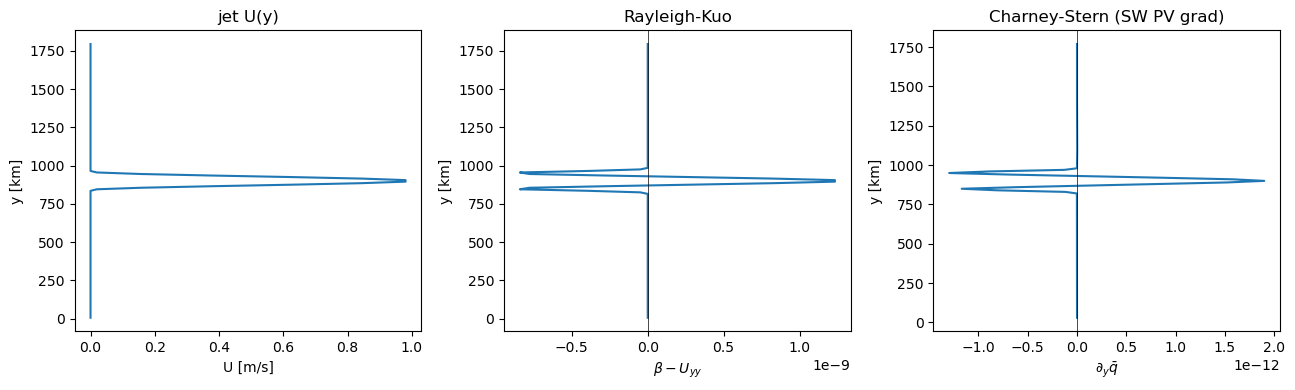

In [4]:
# Barotropic-instability criterion (Rayleigh-Kuo / Charney-Stern): a NECESSARY
# condition for instability is that the background potential-vorticity gradient
# changes sign in the interior. Evaluated on the initial balanced jet.
# See https://en.wikipedia.org/wiki/Rayleigh%E2%80%93Kuo_criterion

U   = M.u[0].mean(axis=1)                          # U(y)
Uyy = np.gradient(np.gradient(U, M.yh1), M.yh1)
RK  = M.beta - Uyy                                 # Rayleigh-Kuo (non-divergent barotropic)
dqdy = np.gradient(M.q(k=0).mean(axis=1), M.yq1)   # Charney-Stern: d/dy of zonal-mean SW PV
dqdy[:3] = np.nan                                  # mask near-wall rows where h->0 makes
dqdy[-2:] = np.nan                                 # q=(f+zeta)/h spike and swamp the interior

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].plot(U, M.yh1/1e3);    ax[0].set_xlabel('U [m/s]'); ax[0].set_ylabel('y [km]'); ax[0].set_title('jet U(y)')
ax[1].plot(RK, M.yh1/1e3);   ax[1].axvline(0, color='k', lw=0.5); ax[1].set_xlabel(r'$\beta - U_{yy}$'); ax[1].set_ylabel('y [km]'); ax[1].set_title('Rayleigh-Kuo')
ax[2].plot(dqdy, M.yq1/1e3); ax[2].axvline(0, color='k', lw=0.5); ax[2].set_xlabel(r'$\partial_y \bar{q}$'); ax[2].set_ylabel('y [km]'); ax[2].set_title('Charney-Stern (SW PV grad)')
fig.tight_layout()
# With the near-wall spike masked, the interior sign change in the SW PV gradient is
# visible in the Charney-Stern panel; the Rayleigh-Kuo panel is the cleaner read.

jj = (M.yh1/M.Ly > 0.12) & (M.yh1/M.Ly < 0.88)     # interior (skip dry walls)
print('Rayleigh-Kuo (beta - U_yy) changes sign in interior:', bool((RK[jj].min() < 0) and (RK[jj].max() > 0)))

## Control (truth) run: record west band + OBC-column probe

`run_record_bc` integrates the free (periodic) model and stores, **every step**:
- the west-band columns (`pres_cols`) — later re-injected by `run_obc` to prescribe the west boundary;
- a 3-column probe at `[b_obc-2, b_obc-1, b_obc]` — column `b_obc` is the *external* data the Orlanski scheme
  needs on inflow, and columns `b-2, b-1` let us replicate the scheme's phase-speed estimator offline (Diagnostic 1-C, 2-B).


In [5]:
b_obc = 150                # [OBC - Orlanski] eastern OBC column (interior; run_obc needs 2 <= b < ni-1)
pres_cols = np.concatenate([west_cols])
ic = (M.u.copy(), M.v.copy(), M.h.copy(), M.time, M.iter)
Store_downstream = True    #   probe at [b-2, b-1, b] is REQUIRED now: external col-b data for run_obc + offline diagnostics

u, v, h, time, h_bc_all, u_bc_all, v_bc_all, probe = M.run_record_bc(
    *run_params, pres_cols,
    store_downstream=Store_downstream, probe_i0=b_obc - 2, n_probe = 3)   #   dropped store_centerline (1D-module-only feature)
# These are the columns for external forcing
h_ext_all = probe['h'][:, :, :, 2] # (nstep, nk, nj) -- column of the boundary, time series   #   uncommented: run_obc requires the ext data
v_ext_all = probe['v'][:, :, :, 2]                                                            #   uncommented
u_ext_all = probe['u'][:, :, :, 2]                                                            #   uncommented


numba threads = 16
CFL: dt*f = 0.02
CFL: dt*cg/dx = 0.16
CFL: dt*nu_h/dx^2 = 0.0004
CFL*: dt*epsilon/h_bot = 6.25e-06
CFL*: dt*nu_v/h_min^2 = 0.0
CFL*: dt*h_relax = 0.002
CFL*: dt*u_relax = 0.002
CFL*: dt*v_relax = 0.002
nsteps = 50000
Time: Trun * fo = 1000.0
Time: Trun * ( cg / L ) = 32.0
[OBC] recording (u,v,h) at boundary columns i = [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]
[OBC] also storing downstream probe at columns i = 148..150
Running (record)...
...done


## Testing, Low Information External Forcing

The current external forcing is perfect. It is identical to the control run. What if the external forcing lack information? Here, the external forcing is just the initial value at the b_obc column

In [6]:
# _nstep_ext = probe['h'].shape[0]
# h_ext_all = np.broadcast_to(ic[2][:, :, b_obc], (_nstep_ext, M.nk, M.nj)).copy()   # h(t=0) at col b_obc
# u_ext_all = np.broadcast_to(ic[0][:, :, b_obc], (_nstep_ext, M.nk, M.nj)).copy()   # u(t=0) at col b_obc
# v_ext_all = np.broadcast_to(ic[1][:, :, b_obc], (_nstep_ext, M.nk, M.nj)).copy()   # v(t=0) at col b_obc

# OBC Run: Prescribed West Boundary + 2D Orlanski East Boundary

West band: hard-replaced from the control stores every step (misfit ~0 by construction). East column `b_obc`:
2D Orlanski radiation on outflow rows, nudging toward the recorded external data on inflow rows
(`nudging=True`, coefficient `ALPHA_IN`; `ALPHA_IN = 0` keeps the previous boundary value on inflow).
The per-row applied Courant numbers $(r_x, r_y)$ of every field are recorded each step by the module's
`[OBC - 2D - PhaseDiag]` hooks and returned in `rx_2d`. The run **also stores $(u,v,h)$ at column `b_obc-1`
every step** (`store_downstream=True` → `rx_2d['probe']`, module hook `[OBC - 2D - Probe]`), so the theory
$c_{th}=u$ is available at step cadence for the online run too.


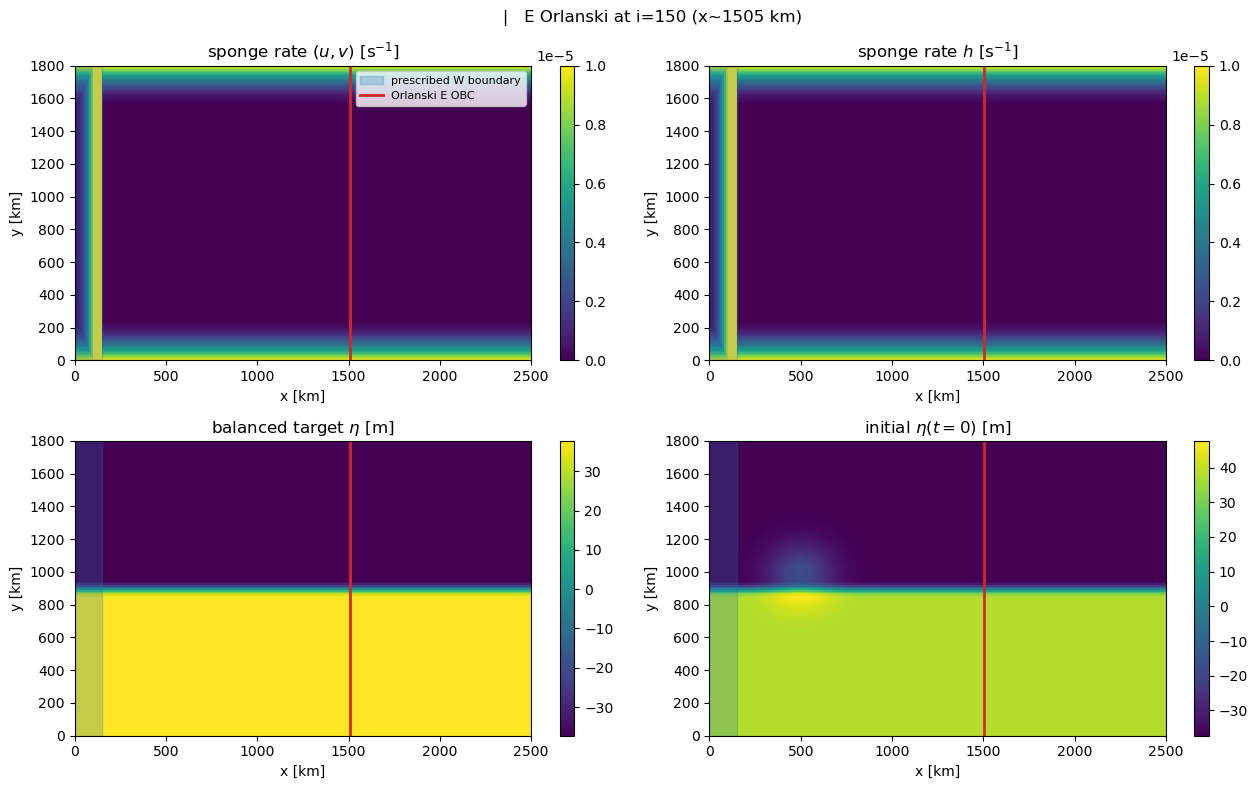

In [7]:
# b_obc = M.ni - 1 - 20                          # [OBC - Orlanski] eastern OBC column (also set in the run cell)
x_km  = M.xh1 / 1e3
y_km  = M.yh1 / 1e3
dx_km = M.dx / 1e3
eta_init = ic[2][0] - M.D                 # initial eta from the IC snapshot
eta_targ = M.h_target[0] - M.D            # balanced target eta
xW0 = x_km[west_cols.min()] - dx_km / 2     # prescribed-W band edges [km]
xW1 = x_km[west_cols.max()] + dx_km / 2
xE  = x_km[b_obc]                         # Orlanski-E column [km]

def _mark(ax):
    ax.axvspan(xW0, xW1, color='tab:blue', alpha=0.25, label='prescribed W boundary')
    ax.axvline(xE, color='tab:red', lw=2, label='Orlanski E OBC')

fig, ax = plt.subplots(2, 2, figsize=(13, 8))
p = ax[0,0].pcolormesh(x_km, y_km, M.u_relax[0]); fig.colorbar(p, ax=ax[0,0]); ax[0,0].set_title(r'sponge rate $(u,v)$ [s$^{-1}$]')
p = ax[0,1].pcolormesh(x_km, y_km, M.h_relax[0]); fig.colorbar(p, ax=ax[0,1]); ax[0,1].set_title(r'sponge rate $h$ [s$^{-1}$]')
p = ax[1,0].pcolormesh(x_km, y_km, eta_targ);     fig.colorbar(p, ax=ax[1,0]); ax[1,0].set_title(r'balanced target $\eta$ [m]')
p = ax[1,1].pcolormesh(x_km, y_km, eta_init);     fig.colorbar(p, ax=ax[1,1]); ax[1,1].set_title(r'initial $\eta(t{=}0)$ [m]')
for a in ax.ravel():
    _mark(a); a.set_xlabel('x [km]'); a.set_ylabel('y [km]')
ax[0,0].legend(loc='upper right', fontsize=8)
fig.suptitle(f'   |   E Orlanski at i={b_obc} (x~{xE:.0f} km)')
fig.tight_layout()

In [8]:
# 2D Orlanski Run
import importlib
import sys
sys.path.insert(0, '../OSSWEM_helpers')
import Remove_periodicity_2D_NS_orlanski
importlib.reload(Remove_periodicity_2D_NS_orlanski)
from Remove_periodicity_2D_NS_orlanski import SSWEM as SSWEM_2D

In [9]:
# Inflow nudging coefficient (fixed; used by the Orlanski update on inflow rows)
# In the note, it is recommended that \tau_in \sim days and here alpha_in = dt / \alpha_in so it is actually really small
tau_in = 2 # In days
ALPHA_IN = 200 / (tau_in * 86400)
ALPHA_IN = 0.0
print(ALPHA_IN)

0.0


In [10]:
M2 = SSWEM_2D(M.ni, M.g, M.Ho, M.Lx, M.fo, M.beta, M.epsilon, M.nu_h,   # [FRESH] duplicate the control run's constructor args from M (no hardcoded constants)
              nu_v=M.nu_v, h_zonal_relax=M.h_zonal_relax, hsub=M.hsub,  # [FRESH]
              nj=M.nj, Ly=M.Ly)                                         # [FRESH] exact grid however M was built
# copy the configured sponge + targets from the 1D model M (set up above)
M2.u_target = M.u_target.copy(); M2.v_target = M.v_target.copy(); M2.h_target = M.h_target.copy()  # [FRESH] +v_target
M2.D[:] = M.D                                                    # [FRESH] bathymetry (dry-row walls etc.) follows M
M2.u_relax  = M.u_relax.copy();  M2.v_relax  = M.v_relax.copy();  M2.h_relax = M.h_relax.copy()
# same initial condition as Sim1 / Sim3-1D
M2.u[:], M2.v[:], M2.h[:] = ic[0], ic[1], ic[2]
M2.time, M2.iter = ic[3], ic[4]

u3_2d, v3_2d, h3_2d, time3_2d, diff3_2d, rx_2d = M2.run_obc(
    *run_params, pres_cols, h_bc_all, u_bc_all, v_bc_all, b_obc,
    nudging=True,                                      # hard-prescribe inflow = phi_ext (matches 1D)
    h_ext_all=h_ext_all, u_ext_all=u_ext_all, v_ext_all=v_ext_all, alpha_in = ALPHA_IN,
    store_downstream=True, probe_i0=b_obc - 1, n_probe=1)   #  [OBC - 2D - Probe] per-step (u,v,h) at b-1 -> rx_2d['probe'] (online theory c_th=u)

del h_bc_all, u_bc_all, v_bc_all


mesh: ni = 250  nj = 180
Grid: dx = 10000.0 [m]  dy = 10000.0 [m]
cg = 8.0 [m s-1]
Ld = 80000.0 [m]
Scales: Ls=epsilon/D/beta = None [m]
Scales: Lx/Ld = 31.25
Res: Ld/dx = 8.0
numba threads = 16
CFL: dt*f = 0.02
CFL: dt*cg/dx = 0.16
CFL: dt*nu_h/dx^2 = 0.0004
CFL*: dt*epsilon/h_bot = 6.25e-06
CFL*: dt*nu_v/h_min^2 = 0.0
CFL*: dt*h_relax = 0.002
CFL*: dt*u_relax = 0.002
CFL*: dt*v_relax = 0.002
nsteps = 50000
Time: Trun * fo = 1000.0
Time: Trun * ( cg / L ) = 32.0
[OBC - Orlanski - 2D - IndepRx] east r_x estimated independently per field (h, u, v)
[OBC - Orlanski - 2D - Nuding] east inflow scheme: NUDGING (alpha_in=0, ghost wall removed)
...done
Mean r_x over run is h = -0.021u=0.001  v=-0.001


# Diagnostics

Everything below reads only:
- `rx_2d['rx_{h,u,v}_row']`, `['ry_{h,u,v}_row']` — per-step, per-row **applied** Courant numbers at `b_obc`
  (shape `(nsteps, nk, nj)`): raw signed values on inflow rows, clamped at 3 on outflow rows
  (`[OBC - 2D - PhaseDiag]` hooks);
- `rx_2d['probe']` — per-step $(u,v,h)$ of the **OBC run** at column `b_obc-1` (`[OBC - 2D - Probe]` hook):
  the online theory $c_{th}=u$ at step cadence;
- the control-run `probe` at `[b-2, b-1, b]` — control theory + exact offline replication of the estimator.

Sign convention at the **east** boundary: $r_x = c_x\,dt/dx$; $r_x > 0$ = outflow (radiate),
$r_x < 0$ = inflow (prescribe/nudge).


## Diagnostic 1 — Spurious inflow: sign of the estimated phase speed

**Theory reference: the advective phase speed $c_{th} = u$ at column `b_obc-1`.** Boundary features (eddies,
vorticity filaments) are carried by the flow, so a correct estimator should return $r_x \approx u\,dt/dx$ —
small and *positive* wherever the boundary flow is eastward. Two bounds put the sign question in context:
- rows with locally $u<0$ (eddy return flow) are the **only** rows where an inflow verdict is physically
  defensible, so the *expected* inflow fraction ≈ the fraction of rows with $u(b{-}1)<0$ (overlaid in D1-B);
- the fast characteristic $u+\sqrt{gh} \approx 8$–$9$ m/s is always positive, so gravity-wave radiation never
  justifies inflow treatment (kept as an auxiliary bound in Diagnostic 2).

Note: on inflow rows the recorded $r_x$ is the *raw* estimate (no clamp), so isolated huge negative values are
possible where the denominator is tiny — the window-median and fraction statistics are robust to this.

Plots: **D1-A** window-cadence Hovmöller, theory vs window-median applied $c_x$ (structure view) ·
**D1-A2** step-cadence **online** Hovmöller from the new `b-1` probe (raw view, shows the row-to-row stripe noise) ·
**D1-B** inflow-fraction Hovmöller + time series / y-profile against the advective expectation ·
**D1-C** offline twin on the control run (uncontaminated, unclamped) · **D1-D** joint histograms + quadrant statistics.


In [11]:
#   ---- Diagnostic 1 setup: shared quantities ----------------------------------------------
assert 'rx_2d' in globals(), 'run the 2D OBC run cell first (defines rx_2d)'                       #  
assert rx_2d.get('probe') is not None, 're-run the OBC run with store_downstream=True (reloaded module with [OBC - 2D - Probe])'   #  
assert list(rx_2d['probe']['cols']) == [b_obc - 1], 'OBC-run probe must sit at column b-1'         #  
assert 'probe' in globals() and probe is not None, 're-run the control run with store_downstream=True'    #  
assert list(probe['cols']) == [b_obc - 2, b_obc - 1, b_obc], 'control probe must cover [b-2, b-1, b]'     #  

K_LAYER = 0                                     #   1-layer jet -> layer 0
BX      = int(b_obc)                            #   east OBC column
DT      = run_params[0]                         #   model step [s]; rx rows are recorded every step
SAMP    = int(run_params[1])                    #   steps per snapshot sample
DXDT    = M2.dx / DT                            #   Courant -> phase speed [m/s]: c_x = r_x * DXDT
G0      = float(M2.g[K_LAYER])                  #   (reduced) gravity (only used for the auxiliary gravity bound)
WIN_STEPS = 100                                 #   stats window for D1-A/D1-B [steps]; theory is per-step now, so this is
                                                #   free to differ from SAMP -- smaller = finer time axis (>=~50 stays robust)

#   theory: ADVECTIVE phase speed c_th = u at column b-1 (features are carried by the flow)
c_th_stp_on = rx_2d['probe']['u'][:, K_LAYER, :, 0]                           #   (nsteps, nj) per step, OBC run
c_th_stp    = probe['u'][:, K_LAYER, :, 1]                                    #   (nsteps, nj) per step, CONTROL run
t_stp_on_d  = np.arange(1, c_th_stp_on.shape[0] + 1) * DT / 86400.0           #   OBC-run step times [days]
t_stp_d     = np.arange(1, c_th_stp.shape[0] + 1) * DT / 86400.0              #   control step times [days]
assert WIN_STEPS <= c_th_stp_on.shape[0], 'WIN_STEPS larger than the run'     #  

def win_view(a2d):                                                            #  
    """(nsteps, nj) step series -> (nwin, WIN_STEPS, nj) whole stats windows."""   #  
    nwin = a2d.shape[0] // WIN_STEPS                                          #   whole windows only (robust to early blow-up)
    return a2d[:nwin * WIN_STEPS].reshape(nwin, WIN_STEPS, a2d.shape[1])      #  

FIELDS = ('h', 'u', 'v')                                                      #  
cx_med, f_in = {}, {}                                                         #  
for _f in FIELDS:                                                             #  
    R = win_view(rx_2d[f'rx_{_f}_row'][:, K_LAYER, :])                        #   applied r_x per window
    cx_med[_f] = np.median(R, axis=1) * DXDT                                  #   window-median applied c_x [m/s]
    f_in[_f]   = (R < 0.0).mean(axis=1)                                       #   window inflow fraction
NWIN      = cx_med['h'].shape[0]                                              #  
t_win_d   = np.arange(1, NWIN + 1) * WIN_STEPS * DT / 86400.0                 #   window END times [days]
c_th_win  = win_view(c_th_stp_on).mean(axis=1)[:NWIN]                         #   window-mean theory, same windows as cx_med
f_in_phys = (win_view(c_th_stp_on) < 0.0).mean(axis=1)[:NWIN]                 #   EXPECTED inflow fraction: rows with u(b-1)<0

for _f in FIELDS:                                                             #  
    print(f'  {_f}: inflow fraction (r_x<0) = {f_in[_f].mean():.3f}   '  #  
          f'median applied c_x = {np.median(cx_med[_f]):+.2f} m/s')           #  
print(f'  advective expectation: fraction of (step,row) with u(b-1)<0 = {(c_th_stp_on < 0).mean():.3f}')   #  
c_gw_med = float(np.median(c_th_stp + np.sqrt(G0 * probe['h'][:, K_LAYER, :, 1])))   #   gravity bound (control, aux)
print(f'  theory c_th = u(b-1): min {c_th_stp_on.min():+.2f}, median {np.median(c_th_stp_on):+.2f}, '      #  
      f'max {c_th_stp_on.max():+.2f} m/s;  gravity bound u+sqrt(gh) ~ {c_gw_med:+.1f} m/s (always > 0)')        #  
print(f'  stats window = {WIN_STEPS} steps = {WIN_STEPS * DT / 3600:.1f} h -> {NWIN} windows on the D1-A/B time axis')   #  


  h: inflow fraction (r_x<0) = 0.533   median applied c_x = -0.01 m/s
  u: inflow fraction (r_x<0) = 0.406   median applied c_x = +0.00 m/s
  v: inflow fraction (r_x<0) = 0.515   median applied c_x = -0.00 m/s
  advective expectation: fraction of (step,row) with u(b-1)<0 = 0.265
  theory c_th = u(b-1): min -0.06, median +0.00, max +0.98 m/s;  gravity bound u+sqrt(gh) ~ +8.2 m/s (always > 0)
  stats window = 100 steps = 5.6 h -> 500 windows on the D1-A/B time axis


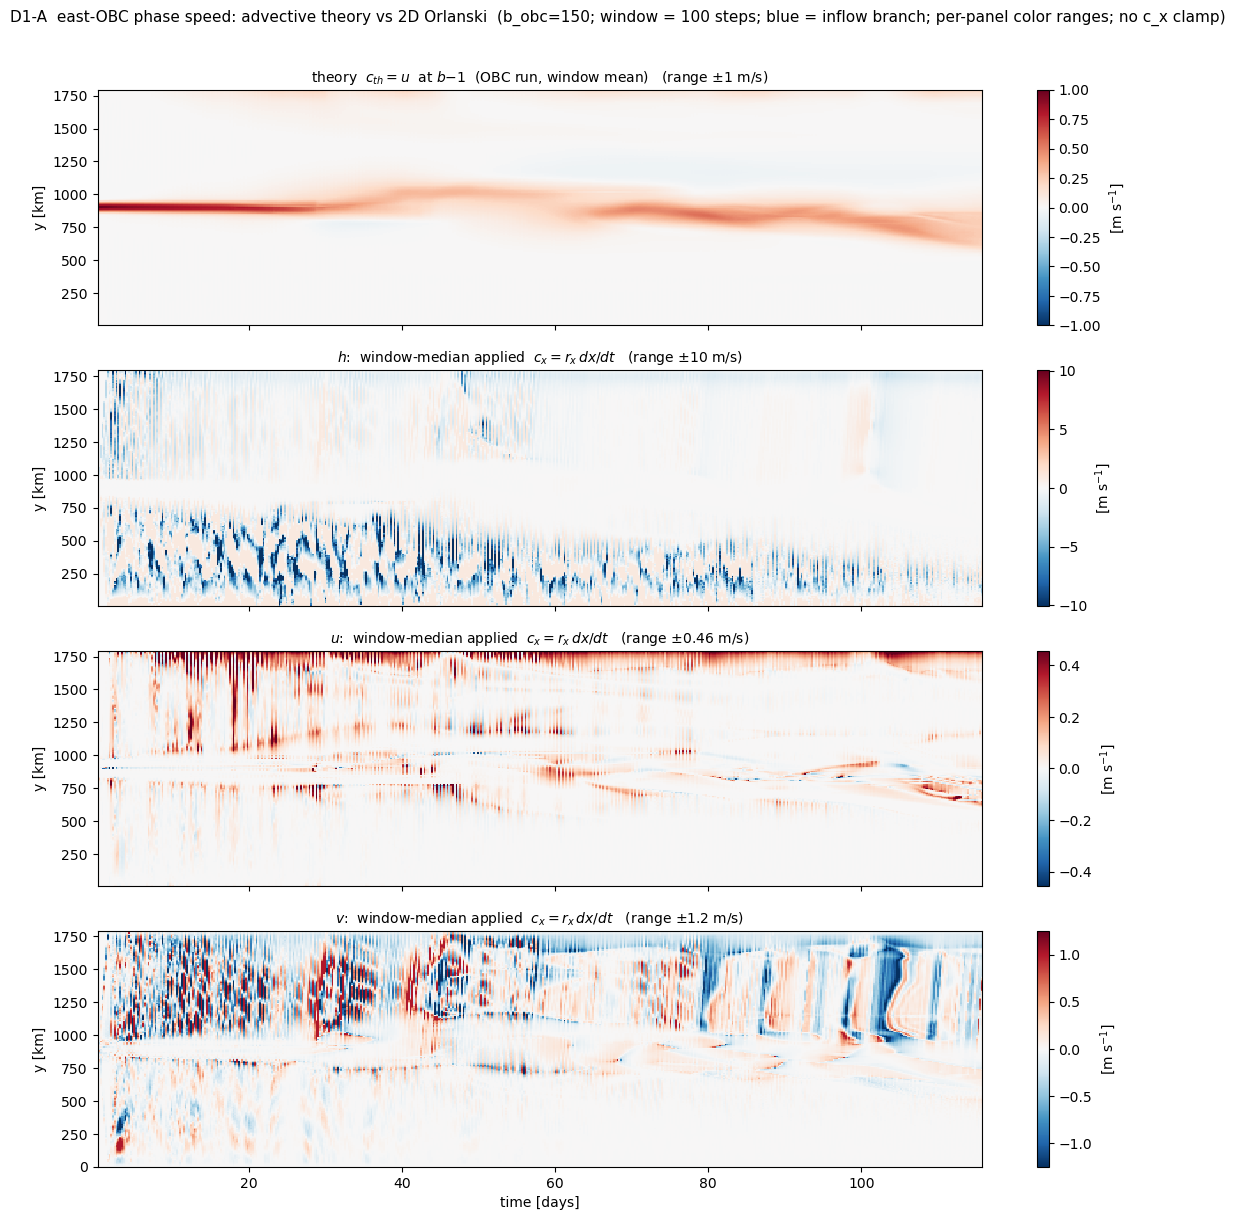

In [12]:
#   ---- D1-A: Hovmoller -- window-mean theory u(b-1) vs window-median applied c_x ---------
#   Time resolution = WIN_STEPS (set in the setup cell); per-step raw view is D1-A2 below.
# [DIAG] Color-range / clamp knobs (panels no longer share one uniform scale):
VLIM_TH  = None                                # [DIAG] theory range [m/s]; None -> auto (99.9th pct of |c_th_win|)
VLIM_CX  = {'h': None, 'u': None, 'v': None}   # [DIAG] per-field c_x range [m/s]; None -> auto (99th pct of |panel|)
CX_CLAMP = None                                # [DIAG] None, or (lo, hi) [m/s]: np.clip the Orlanski c_x before plotting, e.g. (-8.0, 8.0)

ykm_h = M2.yh1 / 1e3                                                          #   h/u rows
ykm_q = M2.yq1 / 1e3                                                          #   v rows

def _auto_vlim(F, pct):                                                       # [DIAG] robust symmetric color range
    return max(float(np.nanpercentile(np.abs(F), pct)), 1e-12)                # [DIAG]

VLIM = float(VLIM_TH) if VLIM_TH is not None else float(np.ceil(_auto_vlim(c_th_win, 99.9)))   # [DIAG] theory scale (D1-A2/C/D reuse VLIM)
panels = [('theory  $c_{th}=u$  at $b{-}1$  (OBC run, window mean)', c_th_win, ykm_h, VLIM)]    # [DIAG] panel = (title, data, y, vlim)
for _f in FIELDS:                                                             # [DIAG]
    Fcx = cx_med[_f] if CX_CLAMP is None else np.clip(cx_med[_f], *CX_CLAMP)  # [DIAG] optional clamp of the Orlanski phase speed
    vl  = float(VLIM_CX[_f]) if VLIM_CX[_f] is not None else _auto_vlim(Fcx, 99.0)   # [DIAG] per-panel range
    panels.append((f'${_f}$:  window-median applied  $c_x = r_x\\,dx/dt$', Fcx,     # [DIAG]
                   ykm_q if _f == 'v' else ykm_h, vl))                        # [DIAG]

fig, axs = plt.subplots(len(panels), 1, figsize=(12, 3.1 * len(panels)), sharex=True)
for ax, (ttl, F, yy, vl) in zip(axs, panels):                                 # [DIAG] per-panel vlim
    im = ax.imshow(F.T, origin='lower', aspect='auto', cmap='RdBu_r',
                   extent=[t_win_d[0], t_win_d[-1], yy[0], yy[-1]],
                   vmin=-vl, vmax=vl, interpolation='nearest')                # [DIAG] panel-specific range
    fig.colorbar(im, ax=ax, label='[m s$^{-1}$]')
    ax.set_title(f'{ttl}   (range \u00b1{vl:.2g} m/s)', fontsize=10); ax.set_ylabel('y [km]')   # [DIAG] range shown per panel
axs[-1].set_xlabel('time [days]')
_cl_txt = 'no c_x clamp' if CX_CLAMP is None else f'c_x clamped to [{CX_CLAMP[0]:g}, {CX_CLAMP[1]:g}] m/s'   # [DIAG]
fig.suptitle(f'D1-A  east-OBC phase speed: advective theory vs 2D Orlanski  (b_obc={BX}; window = {WIN_STEPS} steps; '
             f'blue = inflow branch; per-panel color ranges; {_cl_txt})', fontsize=11)   # [DIAG]
fig.tight_layout(rect=(0, 0, 1, 0.97)); plt.show()


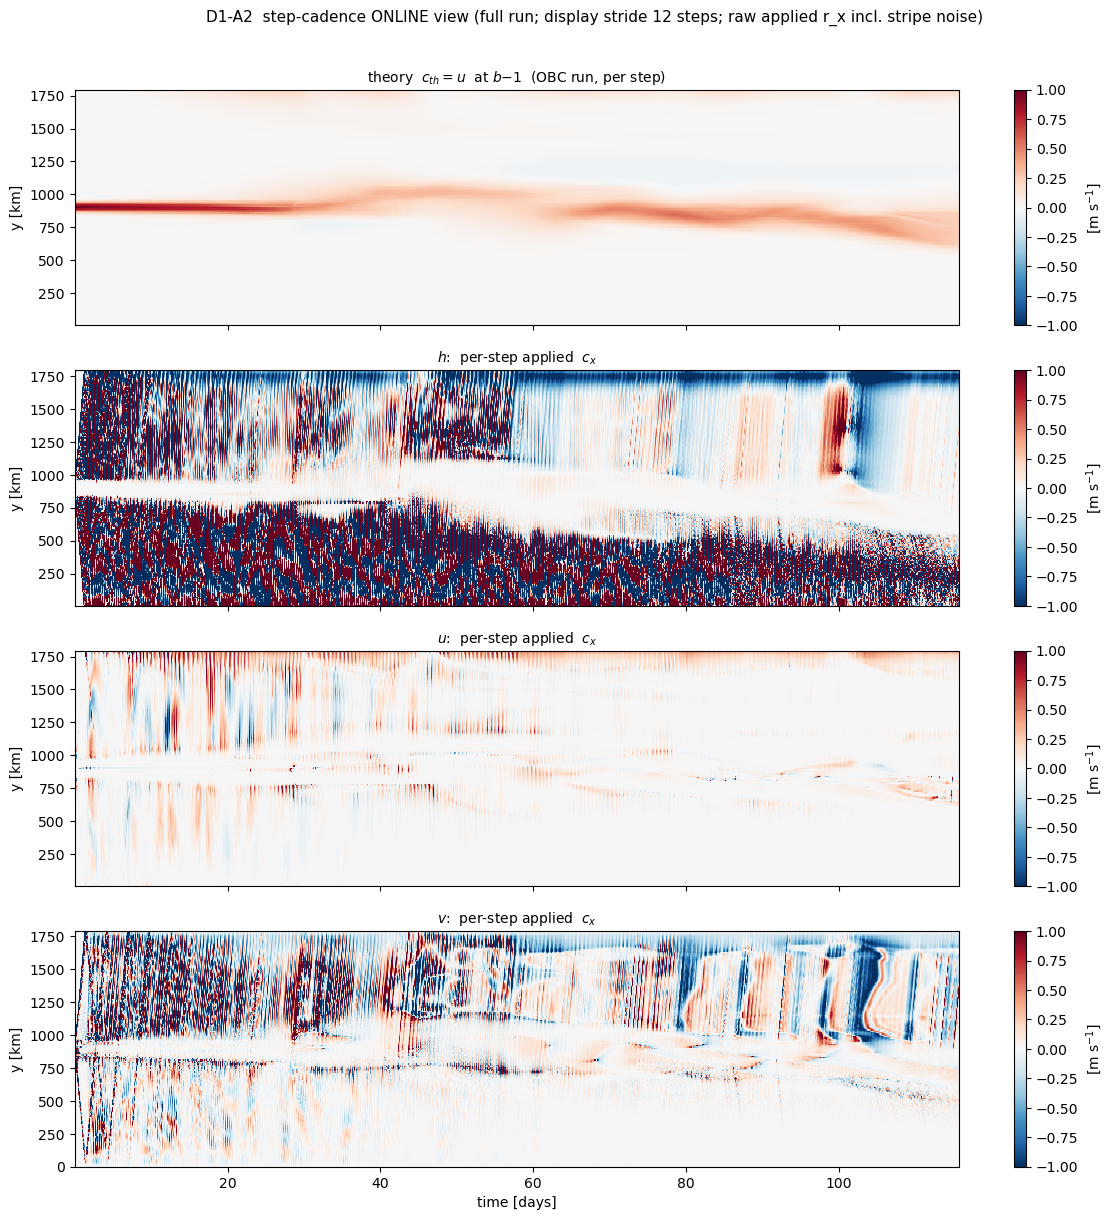

In [13]:
#   ---- D1-A2: ONLINE step-cadence Hovmoller (b-1 probe theory vs per-step applied c_x) ---
#   The full run has ~1.5e5 step columns but the figure has only ~1-2e3 pixel columns, so a
#   whole-run per-step image is necessarily subsampled. For TRUE step-by-step structure set
#   T_ZOOM to a short window in days, e.g. T_ZOOM = (100.0, 105.0)  -> stride drops to 1.
T_ZOOM = None                                                                 
NSTP   = c_th_stp_on.shape[0]                                                   
i0, i1 = 0, NSTP                                                                
if T_ZOOM is not None:                                                          
    i0 = max(0, int(T_ZOOM[0] * 86400.0 / DT))                                  
    i1 = min(NSTP, int(T_ZOOM[1] * 86400.0 / DT))                               
    assert i1 - i0 > 1, 'empty T_ZOOM window'                                   
STP_ON = max(1, (i1 - i0) // 4000)                                            # display stride (1 for short zoom windows)
sl_t   = slice(i0, i1, STP_ON)                                                  
tt_on  = t_stp_on_d[sl_t]                                                       
panels = [('theory  $c_{th}=u$  at $b{-}1$  (OBC run, per step)', c_th_stp_on[sl_t], ykm_h)] + \
         [(f'${_f}$:  per-step applied  $c_x$', rx_2d[f'rx_{_f}_row'][sl_t, K_LAYER, :] * DXDT,     
           ykm_q if _f == 'v' else ykm_h) for _f in FIELDS]                     

fig, axs = plt.subplots(len(panels), 1, figsize=(12, 3.1 * len(panels)), sharex=True)     
for ax, (ttl, F, yy) in zip(axs, panels):                                       
    im = ax.imshow(F.T, origin='lower', aspect='auto', cmap='RdBu_r',           
                   extent=[tt_on[0], tt_on[-1], yy[0], yy[-1]],                 
                   vmin=-VLIM, vmax=VLIM, interpolation='nearest')              
    fig.colorbar(im, ax=ax, label='[m s$^{-1}$]')                               
    ax.set_title(ttl, fontsize=10); ax.set_ylabel('y [km]')                     
axs[-1].set_xlabel('time [days]')                                               
_zoom_txt = 'full run' if T_ZOOM is None else f'zoom {T_ZOOM[0]:g}\u2013{T_ZOOM[1]:g} days'     
fig.suptitle(f'D1-A2  step-cadence ONLINE view ({_zoom_txt}; display stride {STP_ON} steps; raw applied r_x incl. stripe noise)', fontsize=11)   #  
fig.tight_layout(rect=(0, 0, 1, 0.97)); plt.show()                              


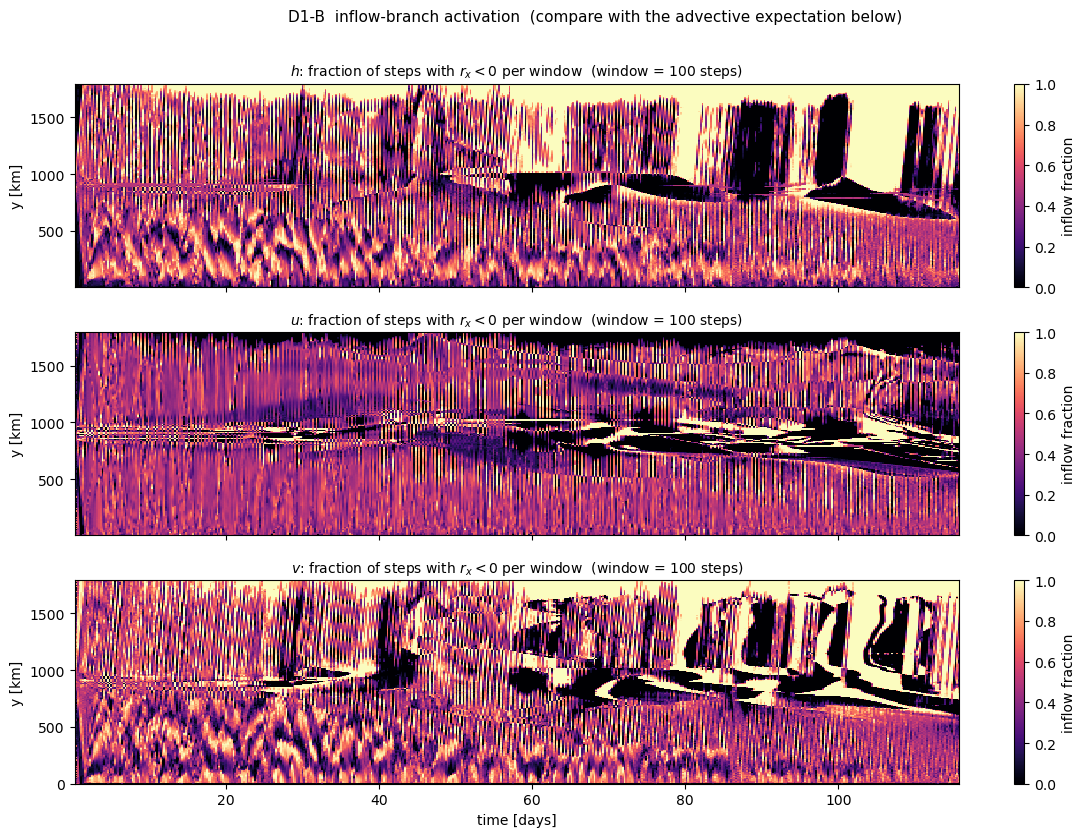

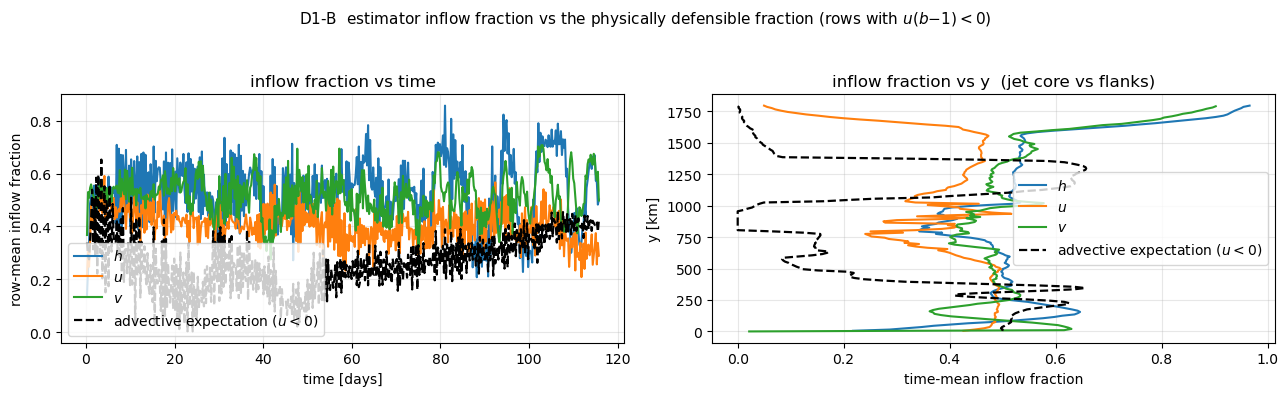

In [14]:
#   ---- D1-B: where/when does the scheme flag inflow? -------------------------------------
fig, axs = plt.subplots(len(FIELDS), 1, figsize=(12, 8.5), sharex=True)       #  
for ax, _f in zip(axs, FIELDS):                                               #  
    yy = ykm_q if _f == 'v' else ykm_h                                        #  
    im = ax.imshow(f_in[_f].T, origin='lower', aspect='auto', cmap='magma',   #  
                   extent=[t_win_d[0], t_win_d[-1], yy[0], yy[-1]],           #  
                   vmin=0.0, vmax=1.0, interpolation='nearest')               #  
    fig.colorbar(im, ax=ax, label='inflow fraction')                          #  
    ax.set_title(f'${_f}$: fraction of steps with $r_x<0$ per window  (window = {WIN_STEPS} steps)', fontsize=10)   #  
    ax.set_ylabel('y [km]')                                                   #  
axs[-1].set_xlabel('time [days]')                                             #  
fig.suptitle('D1-B  inflow-branch activation  (compare with the advective expectation below)', fontsize=11)   #  
fig.tight_layout(rect=(0, 0, 1, 0.97)); plt.show()                            #  

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 4))                         #  
for _f in FIELDS:                                                             #  
    ax0.plot(t_win_d, f_in[_f].mean(axis=1), label=f'${_f}$')                 #   row-mean inflow fraction vs time
    ax1.plot(f_in[_f].mean(axis=0), (ykm_q if _f == 'v' else ykm_h), label=f'${_f}$')   #   time-mean vs y
ax0.plot(t_win_d, f_in_phys.mean(axis=1), 'k--', lw=1.6, label='advective expectation ($u<0$)')   #  
ax1.plot(f_in_phys.mean(axis=0), ykm_h, 'k--', lw=1.6, label='advective expectation ($u<0$)')     #  
ax0.set_xlabel('time [days]'); ax0.set_ylabel('row-mean inflow fraction'); ax0.legend(); ax0.grid(alpha=.3)   #  
ax0.set_title('inflow fraction vs time')                                      #  
ax1.set_xlabel('time-mean inflow fraction'); ax1.set_ylabel('y [km]'); ax1.legend(); ax1.grid(alpha=.3)       #  
ax1.set_title('inflow fraction vs y  (jet core vs flanks)')                   #  
fig.suptitle('D1-B  estimator inflow fraction vs the physically defensible fraction (rows with $u(b{-}1)<0$)', fontsize=11)   #  
fig.tight_layout(rect=(0, 0, 1, 0.94)); plt.show()                            #  


  offline h: inflow fraction (raw r_x<0) = 0.429
  offline u: inflow fraction (raw r_x<0) = 0.432
  offline v: inflow fraction (raw r_x<0) = 0.400


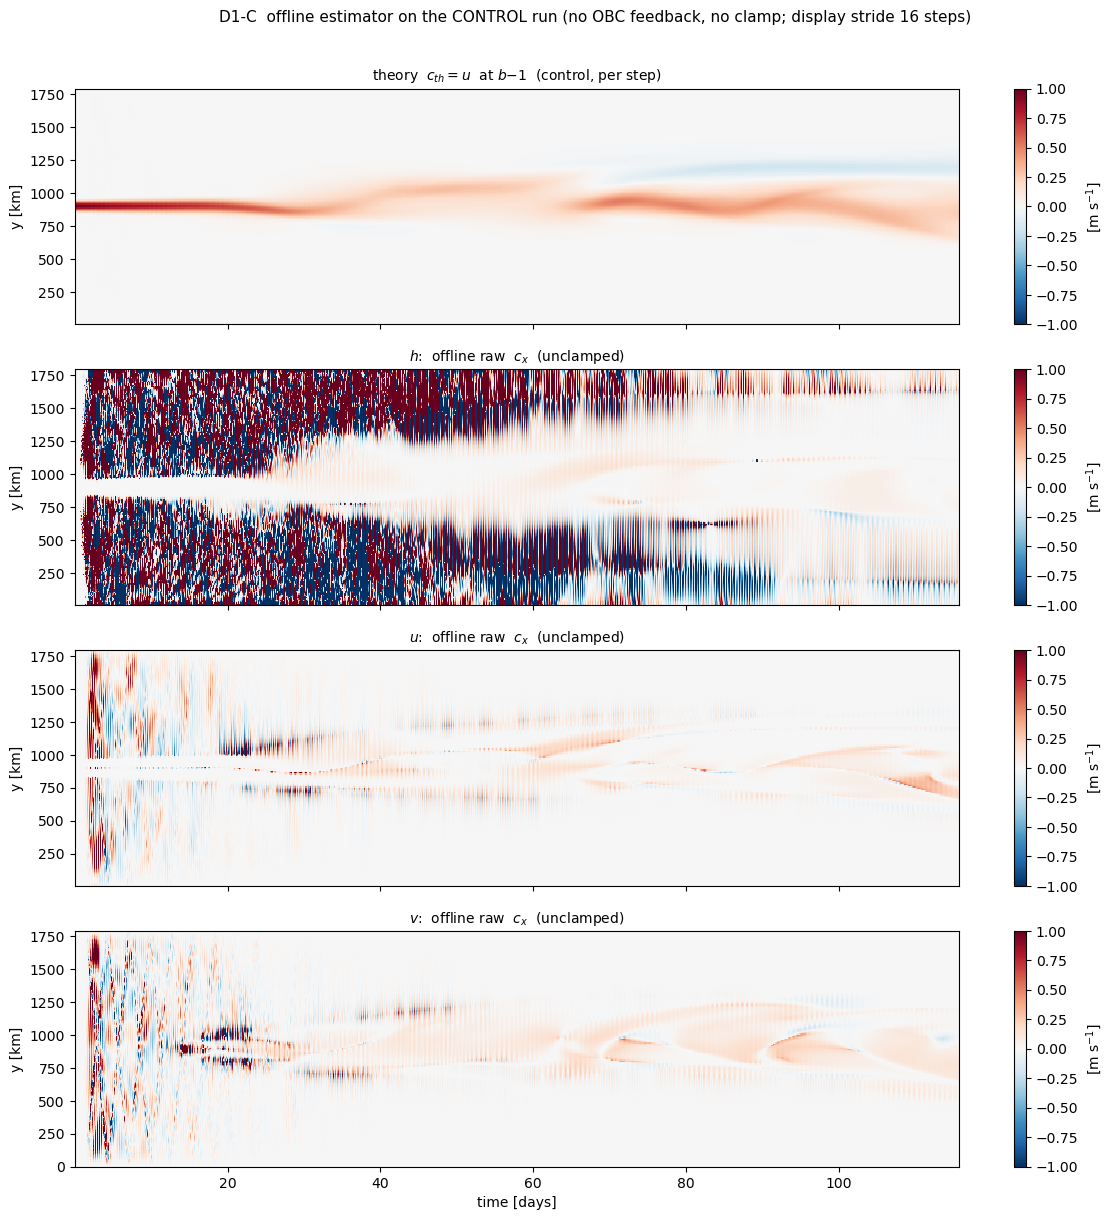

In [15]:
#   ---- D1-C: offline twin on the CONTROL run (exact estimator replication, step cadence) --
#   Replicates _orlanski_east's estimator EXACTLY (mirror-clamp N/S walls [NP], eps_denom floor,
#   same stencil) on the control probe -> the raw r_x the scheme would compute on clean data,
#   BEFORE any boundary-feedback contamination and BEFORE the outflow clamp.
EPS_DENOM = 1e-5                                                              #   must match the module

def orlanski_offline(field):                                                  #  
    """probe field -> per-step estimator pieces at b-1: rx, ry (unclamped), denom, dpt, dpx."""   #  
    P     = probe[field][:, K_LAYER]                                          #   (nsteps, nj, 3): cols [b-2, b-1, b]
    prev  = P[:-1, :, 1]                                                      #   phi^n     at b-1
    pim1  = P[1:,  :, 1]                                                      #   phi^{n+1} at b-1
    pim2  = P[1:,  :, 0]                                                      #   phi^{n+1} at b-2
    dpt   = pim1 - prev                                                       #   time difference
    dpx   = pim1 - pim2                                                       #   normal difference
    jp = np.empty_like(prev); jp[:, :-1] = prev[:, 1:];  jp[:, -1] = prev[:, -1]   #   mirror ghost, north wall [NP]
    jm = np.empty_like(prev); jm[:, 1:]  = prev[:, :-1]; jm[:, 0]  = prev[:, 0]    #   mirror ghost, south wall [NP]
    dpy   = np.where(dpt * (jp - jm) > 0.0, prev - jm, jp - prev)             #   upwinded tangential difference
    denom = dpx**2 + dpy**2                                                   #   |grad phi|^2 (module floors it at EPS_DENOM)
    rd    = 1.0 / np.maximum(denom, EPS_DENOM)                                #  
    out   = {'rx': -dpt * dpx * rd, 'ry': -dpt * dpy * rd,                    #   UNCLAMPED signed Courant numbers
             'denom': denom, 'dpt': dpt, 'dpx': dpx}                          #  
    return {k: v.astype(np.float32) for k, v in out.items()}                  #   float32 store: 5 step-cadence arrays x 3 fields, halves RAM

off = {_f: orlanski_offline(_f) for _f in FIELDS}                             #  

STP = max(1, off['h']['rx'].shape[0] // 3000)                                 #   display stride (imshow economy)
tt  = t_stp_d[1:][::STP]                                                      #  
panels = [('theory  $c_{th}=u$  at $b{-}1$  (control, per step)', c_th_stp[1:][::STP], ykm_h)] + \
         [(f'${_f}$:  offline raw  $c_x$  (unclamped)', off[_f]['rx'][::STP] * DXDT, ykm_q if _f == 'v' else ykm_h)   #  
          for _f in FIELDS]                                                   #  

fig, axs = plt.subplots(len(panels), 1, figsize=(12, 3.1 * len(panels)), sharex=True)   #  
for ax, (ttl, F, yy) in zip(axs, panels):                                     #  
    im = ax.imshow(F.T, origin='lower', aspect='auto', cmap='RdBu_r',         #  
                   extent=[tt[0], tt[-1], yy[0], yy[-1]],                     #  
                   vmin=-VLIM, vmax=VLIM, interpolation='nearest')            #  
    fig.colorbar(im, ax=ax, label='[m s$^{-1}$]')                             #  
    ax.set_title(ttl, fontsize=10); ax.set_ylabel('y [km]')                   #  
axs[-1].set_xlabel('time [days]')                                             #  
for _f in FIELDS:                                                             #  
    print(f'  offline {_f}: inflow fraction (raw r_x<0) = {(off[_f]["rx"] < 0).mean():.3f}')   #  
fig.suptitle(f'D1-C  offline estimator on the CONTROL run (no OBC feedback, no clamp; display stride {STP} steps)', fontsize=11)   #  
fig.tight_layout(rect=(0, 0, 1, 0.97)); plt.show()                            #  


  h offline:  P(r_x<0) = 0.429   spurious P(r_x<0 & u>0) = 0.195   defensible P(r_x<0 & u<0) = 0.234
  h online :  P(med c_x<0) = 0.535   spurious P(<0 & u>0) = 0.387
  h: median offline c_x = +0.008 m/s   vs   median c_th = +0.00 m/s


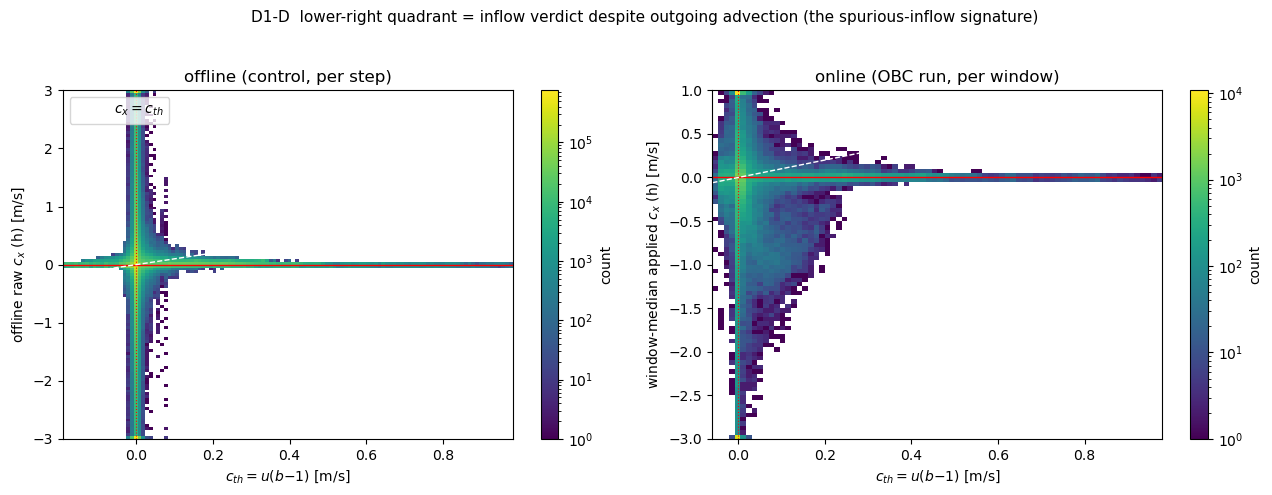

In [16]:
#   ---- D1-D: joint distribution -- scheme estimate vs advective theory -------------------
from matplotlib.colors import LogNorm                                         #  

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))                         #  

xo = c_th_stp[1:].ravel()                                                     #   offline pairs (control, per step): theory u(b-1) ...
yo = np.clip(off['h']['rx'].ravel() * DXDT, -3 * VLIM, 3 * VLIM)              #   ... vs raw c_x for h (display-clipped)
hb = axL.hist2d(xo, yo, bins=120, norm=LogNorm(), cmap='viridis')             #  
fig.colorbar(hb[3], ax=axL, label='count')                                    #  
axL.axhline(0, color='r', lw=1); axL.axvline(0, color='r', lw=0.8, ls=':')    #  
axL.plot([xo.min(), xo.max()], [xo.min(), xo.max()], 'w--', lw=1, label='$c_x=c_{th}$')   #  
axL.set_xlabel('$c_{th} = u(b{-}1)$ [m/s]'); axL.set_ylabel('offline raw $c_x$ (h) [m/s]')   #  
axL.set_title('offline (control, per step)'); axL.legend(loc='upper left')    #  

xw = c_th_win.ravel()                                                         #   online pairs (OBC run, per window)
yw = np.clip(cx_med['h'].ravel(), -3 * VLIM, 3 * VLIM)                        #  
hb2 = axR.hist2d(xw, yw, bins=80, norm=LogNorm(), cmap='viridis')             #  
fig.colorbar(hb2[3], ax=axR, label='count')                                   #  
axR.axhline(0, color='r', lw=1); axR.axvline(0, color='r', lw=0.8, ls=':')    #  
axR.plot([xw.min(), xw.max()], [xw.min(), xw.max()], 'w--', lw=1)             #  
axR.set_xlabel('$c_{th} = u(b{-}1)$ [m/s]'); axR.set_ylabel('window-median applied $c_x$ (h) [m/s]')   #  
axR.set_title('online (OBC run, per window)')                                 #  

rx_h_off = off['h']['rx'].ravel()                                             #  
print(f'  h offline:  P(r_x<0) = {(rx_h_off < 0).mean():.3f}   '         #  
      f'spurious P(r_x<0 & u>0) = {((rx_h_off < 0) & (xo > 0)).mean():.3f}   '            #  
      f'defensible P(r_x<0 & u<0) = {((rx_h_off < 0) & (xo < 0)).mean():.3f}')            #  
print(f'  h online :  P(med c_x<0) = {(cx_med["h"].ravel() < 0).mean():.3f}   '      #  
      f'spurious P(<0 & u>0) = {((cx_med["h"].ravel() < 0) & (xw > 0)).mean():.3f}')      #  
print(f'  h: median offline c_x = {np.median(rx_h_off) * DXDT:+.3f} m/s   vs   median c_th = {np.median(xo):+.2f} m/s')   #  
fig.suptitle('D1-D  lower-right quadrant = inflow verdict despite outgoing advection (the spurious-inflow signature)', fontsize=11)   #  
fig.tight_layout(rect=(0, 0, 1, 0.95)); plt.show()                            #  


## Diagnostic 2 — Non-physical phase-speed magnitude: plan

**Claim.** Even on outflow rows the estimated $c_x = r_x\,dx/dt$ is not a physical propagation speed. The expected
scale is the advective $c_{th} = u$ ($\lesssim 1.5$ m/s), and no meaningful radiation speed exceeds the gravity-wave
bound $u+\sqrt{gh} \approx 8$–$9$ m/s; the estimator instead produces values controlled by near-zero denominators
(`eps_denom` floor), single-cell noise (the known $2\Delta y$ stripe pattern from per-row sign flicker), and the
hard clamp $r_x \le 3$ (150 m/s).

**Mechanism to verify.** $r_x = -\Delta\phi_t\,\Delta\phi_x / (\Delta\phi_x^2 + \Delta\phi_y^2)$ is a pointwise
0/0-type ratio: wherever the local gradient is small, the ratio is noise — its sign flips row-to-row
(inflow/outflow branch flicker → stripes) and its magnitude is meaningless. Note `eps_denom = 1e-5` is an
**absolute** threshold with field-dependent meaning: $\Delta h = O(1\,\mathrm{m})$ but $\Delta u = O(10^{-2}\,\mathrm{m/s})$,
so $u$ and $v$ hit the floor far more often than $h$ — D2-B quantifies this.

**Step 1 — quantify against reference speeds (offline; implemented below).**
D2-A: distributions of applied $c_x$ per field vs $u(b{-}1)$ ($=c_{th}$), the gravity bound $u+\sqrt{gh}$, $dx/dt$,
and the clamp; failure-regime occupancy: % inflow, % clamped at $r_x=3$, % in the advective band
($0 \le r_x \le r_x^{adv}$), % under the gravity bound, % denominator-floored.
D2-B: Hovmöller of $\log_{10}(\mathrm{denom})$ + joint histogram $|r_x|$ vs denom — do extreme $|r_x|$ concentrate where the gradient collapses?

**Step 2 — statistical structure (next).** Autocorrelation of $r_x$ in $j$ and $t$: a physical phase speed varies on the
eddy scale (~100 km, ~days); stripe noise decorrelates in 1–2 cells / 1–2 steps. Compare against the decorrelation
scales of $u(b{-}1)$ and of the field itself.

**Step 3 — better estimators, evaluated offline on the probe first (no module change).**
- $j$-smoothed / boundary-median $r_x$ before the inflow/outflow branch decision (the known stripe fix);
- time-filtered $r_x$ (Orlanski 1976 lagged levels; ROMS-style running average);
- least-squares fit of $c$ from $\phi_t + c\,\phi_x = 0$ over the 3 probe columns × a few steps;
- theory-informed clamp: $r_x \in [0,\ r_x^{adv} \approx 0.03]$ (advective) or $[0,\ (u+\sqrt{gh})\,dt/dx \approx 0.19]$ (gravity bound) instead of $[0, 3]$.
Score each by sign agreement and magnitude error vs $u(b{-}1)$ before touching the model.

**Step 4 — online A/B tests (require module changes — see proposals in the final cell; not applied).** Rank by
interior RMS vs control: baseline vs smoothed-$r_x$ vs theory-clamped vs a fixed-speed Sommerfeld condition with
$c = u(b{-}1)$ (advective, $=c_{th}$) or $c = u+\sqrt{gh}$. If a fixed physical speed wins, the phase-speed
estimate — not the radiation form — is the dominant Orlanski error.


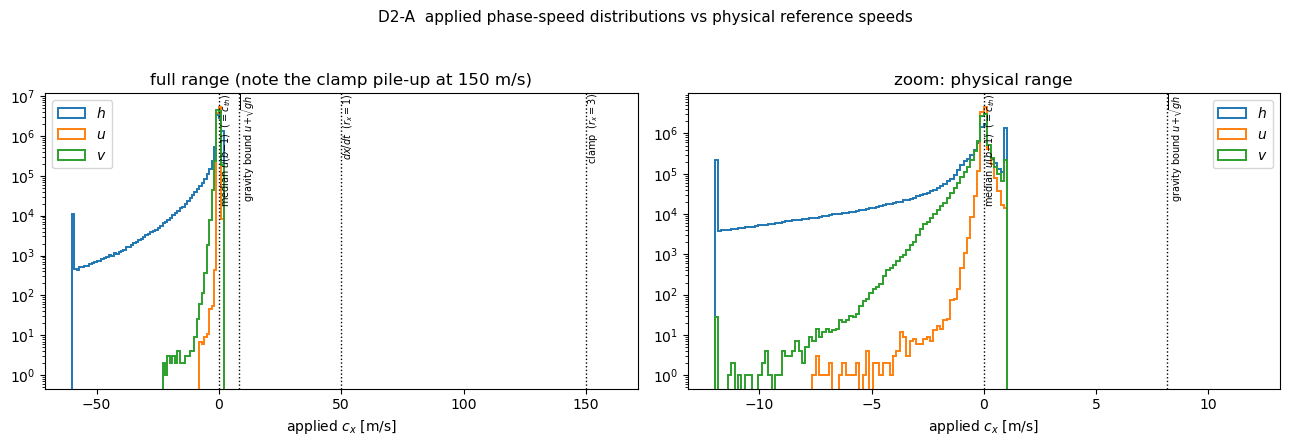

  failure-regime occupancy (per step x row):
  h:  inflow (r_x<0):  53.3%   clamped (r_x>=3):   0.0%   advective band (0<=r_x<=0.005):  22.7%   under gravity bound (0<=r_x<=0.16):  46.7%   denom<eps (offline):  16.7%
  u:  inflow (r_x<0):  40.6%   clamped (r_x>=3):   0.0%   advective band (0<=r_x<=0.005):  54.9%   under gravity bound (0<=r_x<=0.16):  59.4%   denom<eps (offline):  72.3%
  v:  inflow (r_x<0):  51.5%   clamped (r_x>=3):   0.0%   advective band (0<=r_x<=0.005):  38.7%   under gravity bound (0<=r_x<=0.16):  48.5%   denom<eps (offline):  75.1%


In [17]:
#   ---- D2-A: magnitude distributions & failure-regime occupancy ---------------------------
assert 'off' in globals(), 'run the D1-C cell first (defines the offline estimator pieces `off`)'   #  
u_b1     = probe['u'][:, K_LAYER, :, 1]                                       #   control u at b-1
u_b1_med = float(np.median(u_b1))                                             #   advective reference = median c_th [m/s]
RX_ADV   = float(np.percentile(np.abs(u_b1), 95)) / DXDT                      #   advective Courant band (~0.02-0.03)
RX_GW    = c_gw_med / DXDT                                                    #   gravity-bound Courant (~0.17); c_gw_med from the setup cell
REFS = [(u_b1_med, 'median $u(b{-}1)$  ($=c_{th}$)'), (c_gw_med, 'gravity bound $u{+}\\sqrt{gh}$'),   #  
        (DXDT, '$dx/dt$  ($r_x{=}1$)'), (3 * DXDT, 'clamp  ($r_x{=}3$)')]     #  

fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))                              #  
BINS = np.linspace(-60, 160, 221)                                             #  
for _f in FIELDS:                                                             #  
    cx_all = rx_2d[f'rx_{_f}_row'][:, K_LAYER, :].ravel() * DXDT              #   applied (online) c_x, per step x row
    axs[0].hist(np.clip(cx_all, BINS[0], BINS[-1]), bins=BINS, histtype='step', lw=1.4, label=f'${_f}$')            #  
    axs[1].hist(np.clip(cx_all, -12, 12), bins=np.linspace(-12, 12, 161), histtype='step', lw=1.4, label=f'${_f}$')  #  
for ax in axs:                                                                #  
    ax.set_yscale('log')                                                      #  
    for xr, lab in REFS:                                                      #  
        if ax is axs[1] and xr > 12:                                          #  
            continue                                                          #  
        ax.axvline(xr, color='k', ls=':', lw=1)                               #  
        ax.text(xr, ax.get_ylim()[1], lab, rotation=90, fontsize=7, va='top') #  
    ax.set_xlabel('applied $c_x$ [m/s]'); ax.legend()                         #  
axs[0].set_title('full range (note the clamp pile-up at 150 m/s)'); axs[1].set_title('zoom: physical range')   #  
fig.suptitle('D2-A  applied phase-speed distributions vs physical reference speeds', fontsize=11)   #  
fig.tight_layout(rect=(0, 0, 1, 0.94)); plt.show()                            #  

print('  failure-regime occupancy (per step x row):')                    #  
for _f in FIELDS:                                                             #  
    r   = rx_2d[f'rx_{_f}_row'][:, K_LAYER, :]                                #   applied r_x (online)
    flr = (off[_f]['denom'] < EPS_DENOM).mean()                               #   denominator floored (offline proxy)
    print(f'  {_f}:  inflow (r_x<0): {(r < 0).mean():6.1%}   clamped (r_x>=3): {(r >= 3.0).mean():6.1%}   '     #  
          f'advective band (0<=r_x<={RX_ADV:.3f}): {((r >= 0) & (r <= RX_ADV)).mean():6.1%}   '                 #  
          f'under gravity bound (0<=r_x<={RX_GW:.2f}): {((r >= 0) & (r <= RX_GW)).mean():6.1%}   '              #  
          f'denom<eps (offline): {flr:6.1%}')                                                                   #  


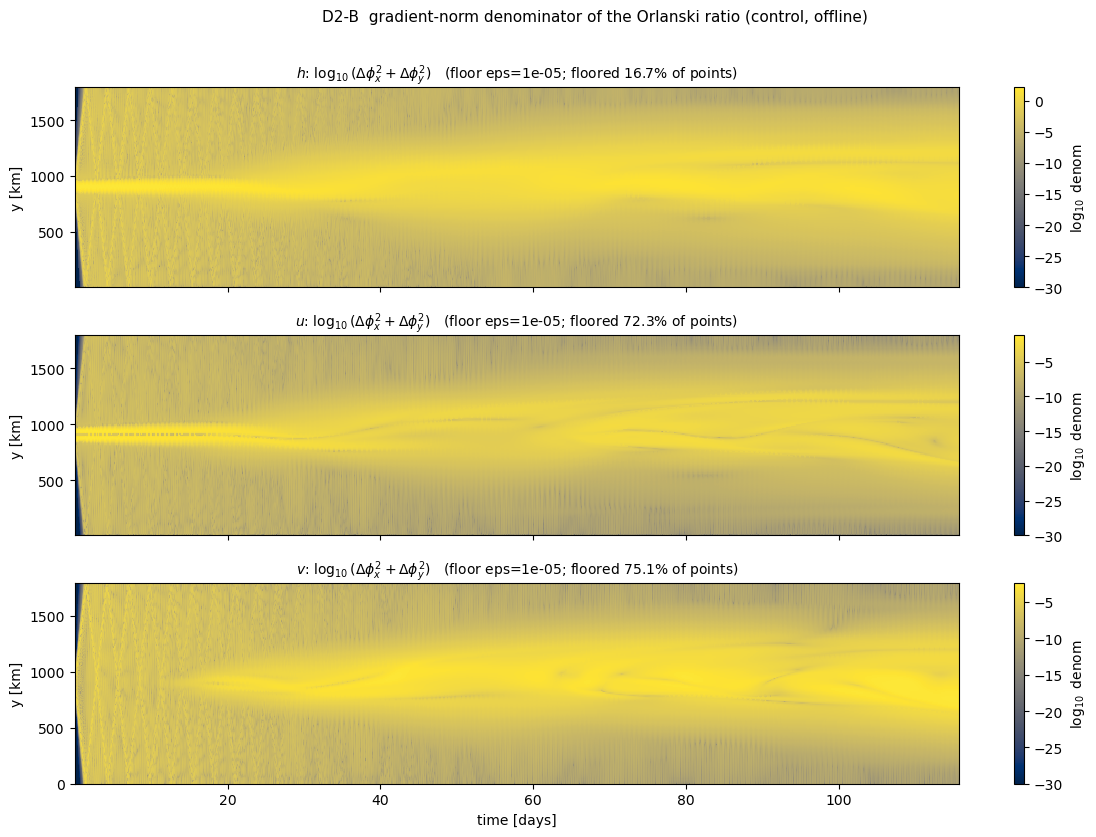

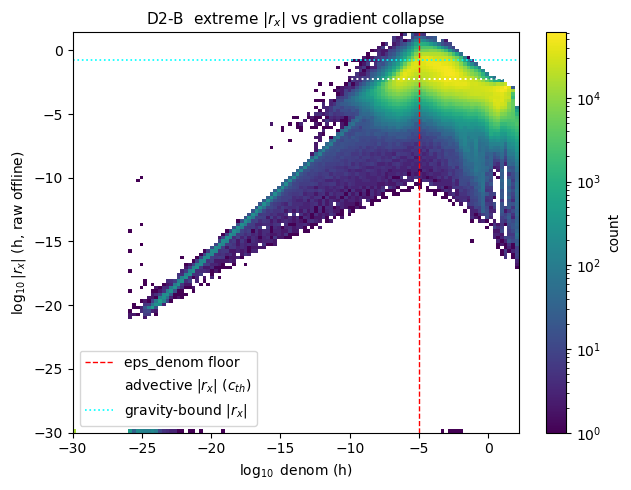

In [18]:
#   ---- D2-B: estimator decomposition -- where does the denominator collapse? -------------
from matplotlib.colors import LogNorm                                         #  
assert 'off' in globals(), 'run the D1-C cell first (defines the offline estimator pieces `off`)'   #  
assert 'RX_ADV' in globals(), 'run the D2-A cell first (defines RX_ADV / RX_GW)'                    #  

fig, axs = plt.subplots(len(FIELDS), 1, figsize=(12, 8.5), sharex=True)       #  
for ax, _f in zip(axs, FIELDS):                                               #  
    dn = off[_f]['denom'][::STP]                                              #   strided like D1-C
    yy = ykm_q if _f == 'v' else ykm_h                                        #  
    im = ax.imshow(np.log10(dn + 1e-30).T, origin='lower', aspect='auto',     #  
                   extent=[tt[0], tt[-1], yy[0], yy[-1]], cmap='cividis', interpolation='nearest')   #  
    fig.colorbar(im, ax=ax, label='$\\log_{10}$ denom')                       #  
    ax.set_title(f'${_f}$: $\\log_{{10}}(\\Delta\\phi_x^2+\\Delta\\phi_y^2)$   '            #  
                 f'(floor eps={EPS_DENOM:g}; floored {(off[_f]["denom"] < EPS_DENOM).mean():.1%} of points)', fontsize=10)   #  
    ax.set_ylabel('y [km]')                                                   #  
axs[-1].set_xlabel('time [days]')                                             #  
fig.suptitle('D2-B  gradient-norm denominator of the Orlanski ratio (control, offline)', fontsize=11)   #  
fig.tight_layout(rect=(0, 0, 1, 0.97)); plt.show()                            #  

fig, ax = plt.subplots(figsize=(6.5, 5))                                      #  
dn = off['h']['denom'].ravel(); rr = np.abs(off['h']['rx'].ravel())           #  
hb = ax.hist2d(np.log10(dn + 1e-30), np.log10(rr + 1e-30), bins=120, norm=LogNorm(), cmap='viridis')   #  
fig.colorbar(hb[3], ax=ax, label='count')                                     #  
ax.axvline(np.log10(EPS_DENOM), color='r', ls='--', lw=1, label='eps_denom floor')                     #  
ax.axhline(np.log10(RX_ADV), color='w', ls=':', lw=1.4, label='advective $|r_x|$ ($c_{th}$)')          #  
ax.axhline(np.log10(RX_GW), color='cyan', ls=':', lw=1.2, label='gravity-bound $|r_x|$')               #  
ax.set_xlabel('$\\log_{10}$ denom (h)'); ax.set_ylabel('$\\log_{10} |r_x|$ (h, raw offline)')        #  
ax.legend(loc='lower left'); ax.set_title('D2-B  extreme $|r_x|$ vs gradient collapse', fontsize=11)   #  
fig.tight_layout(); plt.show()                                                #  


## Proposed module changes — status

**Deployed** (2026-07-13): the per-step OBC-run probe at `b_obc-1` — `run_obc(..., store_downstream=True,
probe_i0, n_probe)` → `rx_2d['probe']`, tagged `[OBC - 2D - Probe]` in `Remove_periodicity_2D_NS_orlanski.py`
(mirrors `run_record_bc`; default off, return signature unchanged). This powers D1-A2 and the online theory.

**Pending — say the word and I'll draft any as a tagged patch:**
1. **Record the raw estimator online** — also store pre-clamp $r_x$, `denom`, $\Delta\phi_t$, $\Delta\phi_x$ per
   row/step (extend `rxy_out` with extra slots), so failure-regime statistics no longer rely on the offline control-run proxy.
2. **Boundary-smoothed phase speed** — median/mean of $r_x$ over a $j$-window (or the whole boundary) *before* the
   inflow/outflow branch decision — the known fix for the $2\Delta y$ stripes.
3. **Theory-informed clamp** — outflow clamp $r_x \in [0,\ r_x^{adv} \approx 0.03]$ (advective) or
   $[0,\ (u+\sqrt{gh})\,dt/dx \approx 0.19]$ (gravity bound) instead of $[0, 3]$.
4. **Fixed physical phase speed (Sommerfeld/Flather-like)** — bypass the estimator and radiate every row with a
   prescribed $c$: either the advective $c = u(b{-}1)$ ($=c_{th}$) or the gravity bound $u+\sqrt{gh}$, per row/step.
   Ranking these against the estimator online (interior RMS vs control) isolates whether the phase-speed estimate
   is the dominant Orlanski error.
5. **Time-filtered $r_x$** — relax $r_x$ toward its previous-step value (ROMS-style) before use.
